In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

MAX_CARS = 20
MAX_MOVE = 5
RENTAL_INCOME = 10.0
MOVE_COST = 2.0
GAMMA = 0.9
REQUEST_RATES = (3, 4)
RETURN_RATES = (3, 2)

In [2]:
def capped_poisson_probs(rate, cap):
    """P(min(Poisson(rate), cap) == k), for k=0,...,cap."""
    if cap == 0:
        return np.array([1.0])
    result = poisson.pmf(np.arange(cap + 1), rate)
    result[-1] = poisson.sf(cap - 1, rate)
    return result

In [ ]:
def location_model(request_rate, return_rate):
    """Expected rental revenue and end-of-day transition for each starting count."""
    transition = np.zeros((MAX_CARS + 1, MAX_CARS + 1))
    revenue = np.zeros(MAX_CARS + 1)
    for start in range(MAX_CARS + 1):
        rental_probs = capped_poisson_probs(request_rate, start)
        for rented, p_rented in enumerate(rental_probs):
            revenue[start] += RENTAL_INCOME * rented * p_rented
            after_rental = start - rented
            return_probs = capped_poisson_probs(return_rate, MAX_CARS - after_rental)
            for returned, p_returned in enumerate(return_probs):
                transition[start, after_rental + returned] += (p_rented * p_returned)
    assert np.allclose(transition.sum(axis=1), 1.0)
    return revenue, transition

In [4]:
def legal_actions(cars_1, cars_2):
    """Only actions with enough origin cars and room at the destination."""
    low = max(-MAX_MOVE, -cars_2, cars_1 - MAX_CARS)
    high = min(MAX_MOVE, cars_1, MAX_CARS - cars_2)
    return range(low, high + 1)

In [ ]:
def immediate_moving_cost(action, modified):
    if modified:
        # First car from location 1 to location 2 is free, if moved.
        return MOVE_COST * (abs(action) - (action > 0))
    return MOVE_COST * abs(action)

def action_value(cars_1, cars_2, action, after_move_return, modified):
    n1, n2 = cars_1 - action, cars_2 + action
    parking = 4.0 * ((n1 > 10) + (n2 > 10)) if modified else 0.0
    return (after_move_return[n1, n2] - immediate_moving_cost(action, modified) - parking)

In [ ]:
def policy_iteration(modified=False, theta=1e-9):
    revenue_1, transition_1 = location_model(REQUEST_RATES[0], RETURN_RATES[0])
    revenue_2, transition_2 = location_model(REQUEST_RATES[1], RETURN_RATES[1])

    values = np.zeros((MAX_CARS + 1, MAX_CARS + 1))
    policy = np.zeros_like(values, dtype=int)
    history = [policy.copy()]
    sweeps_per_iteration = []

    for iteration in range(100):
        # Evaluation: update V under the current policy until convergence.
        for sweep in range(10000):
            # H[i,j] is the expected revenue plus discounted continuation after moving, with i and j cars at the two locations.
            after_move_return = (revenue_1[:, None] + revenue_2[None, :] + GAMMA * (transition_1 @ values @ transition_2.T))
            updated = np.empty_like(values)
            for cars_1 in range(MAX_CARS + 1):
                for cars_2 in range(MAX_CARS + 1):
                    action = int(policy[cars_1, cars_2])
                    updated[cars_1, cars_2] = action_value(cars_1, cars_2, action, after_move_return, modified)
            delta = np.max(np.abs(updated - values))
            values = updated
            if delta < theta:
                break
        else:
            raise RuntimeError("Policy evaluation did not converge")
        sweeps_per_iteration.append(sweep + 1)

        # Improvement: prefer the old action on ties to prevent cycling.
        after_move_return = (revenue_1[:, None] + revenue_2[None, :] + GAMMA * (transition_1 @ values @ transition_2.T))
        stable = True
        for cars_1 in range(MAX_CARS + 1):
            for cars_2 in range(MAX_CARS + 1):
                old_action = int(policy[cars_1, cars_2])
                options = list(legal_actions(cars_1, cars_2))
                scores = np.array([action_value(cars_1, cars_2, action, after_move_return, modified) for action in options])
                best_score = scores.max()
                old_score = scores[options.index(old_action)]
                if best_score > old_score + 1e-10:
                    policy[cars_1, cars_2] = options[int(scores.argmax())]
                    stable = False
        if stable:
            return policy, values, history, sweeps_per_iteration
        history.append(policy.copy())
    raise RuntimeError("Policy iteration did not converge")

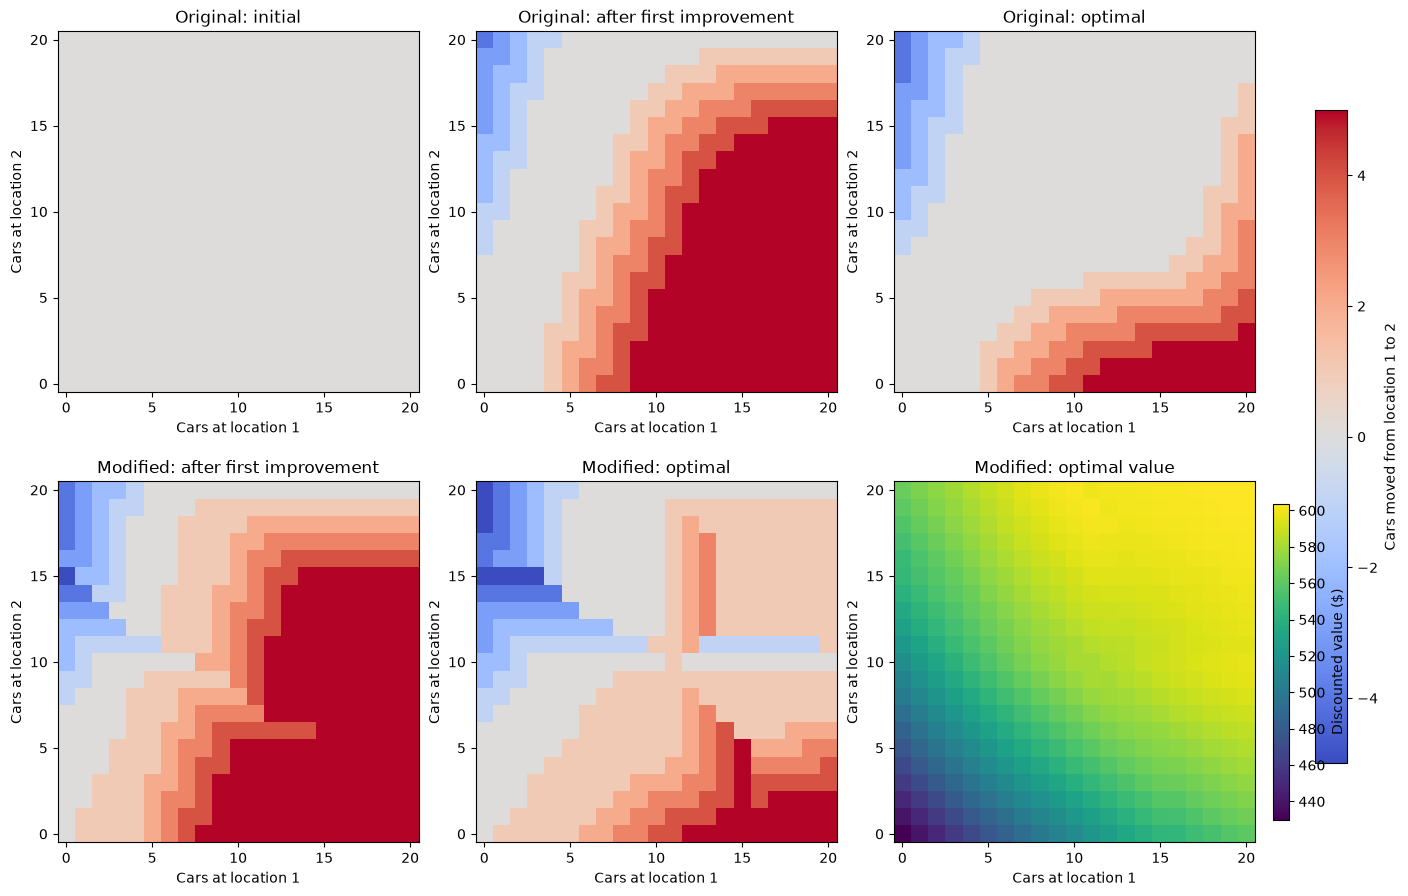

Original: 4 policy improvements, evaluation sweeps [235, 201, 189, 154, 81]
  (0, 0): move +0, V=421.414
  (5, 5): move +0, V=512.219
  (10, 10): move +0, V=574.948
  (10, 20): move +0, V=618.840
  (20, 10): move +2, V=605.831
  (20, 20): move +0, V=636.990
Modified: 3 policy improvements, evaluation sweeps [235, 208, 193, 161]
  (0, 0): move +0, V=429.946
  (5, 5): move +1, V=521.741
  (10, 10): move +0, V=580.963
  (10, 20): move +0, V=602.103
  (20, 10): move +0, V=597.002
  (20, 20): move +0, V=603.491
Policy differences: 242 of 441 states


In [ ]:
def plot_results(original, modified):
    original_policy, original_v, original_history, _ = original
    modified_policy, modified_v, modified_history, _ = modified
    fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)
    all_policies = [original_history[0], original_history[1], original_policy, modified_history[1], modified_policy]
    titles = [
        "Original: initial", 
        "Original: after first improvement",
        "Original: optimal", "Modified: after first improvement",
        "Modified: optimal"
        ]
    for ax, data, title in zip(axes.flat[:5], all_policies, titles):
        im = ax.imshow(data.T, origin="lower", vmin=-5, vmax=5, cmap="coolwarm", interpolation="nearest")
        ax.set_title(title)
        ax.set_xlabel("Cars at location 1")
        ax.set_ylabel("Cars at location 2")
        ax.set_xticks([0, 5, 10, 15, 20])
        ax.set_yticks([0, 5, 10, 15, 20])
    fig.colorbar(im, ax=axes.flat[:5], shrink=0.75, label="Cars moved from location 1 to 2")
    ax = axes.flat[5]
    vimg = ax.imshow(modified_v.T, origin="lower", cmap="viridis")
    fig.colorbar(vimg, ax=ax, shrink=0.75, label="Discounted value ($)")
    ax.set_title("Modified: optimal value")
    ax.set_xlabel("Cars at location 1")
    ax.set_ylabel("Cars at location 2")
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_yticks([0, 5, 10, 15, 20])
    plt.show()


def main():
    original = policy_iteration(modified=False)
    modified = policy_iteration(modified=True)
    plot_results(original, modified)
    for label, result in (("Original", original), ("Modified", modified)):
        policy, values, history, sweeps = result
        print(f"{label}: {len(history)-1} policy improvements, "
              f"evaluation sweeps {sweeps}")
        for state in [(0, 0), (5, 5), (10, 10), (10, 20), (20, 10), (20, 20)]:
            print(f"  {state}: move {policy[state]:+d}, "
                  f"V={values[state]:.3f}")
    print("Policy differences:", np.count_nonzero(original[0] != modified[0]), "of 441 states")

if __name__ == "__main__":
    main()